In [41]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, NNConv

In [42]:
# ============================================================
# 2. PROJECT PATH AND DATABASE CONNECTION
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

db_path = project_root / "data" / "thesis_database.db"

print("Project root:", project_root)
print("Database path:", db_path)
print("Database exists:", db_path.exists())

conn = sqlite3.connect(db_path)

print("Connected to database")

Project root: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool
Database path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db
Database exists: True
Connected to database


In [43]:
# ============================================================
# 3. LOAD SELECTED BIDDING ZONES
# ============================================================

zones_df = pd.read_sql_query(
    """
    SELECT *
    FROM BiddingZones
    ORDER BY zone_id;
    """,
    conn
)

selected_zone_codes = [
    "NO1", "NO2", "NO3", "NO4", "NO5",
    "SE1", "SE2", "SE3", "SE4",
    "DK1", "DK2",
    "FI",
]

selected_zones = (
    zones_df[zones_df["zone_code"].isin(selected_zone_codes)]
    .copy()
    .sort_values("zone_code")
    .reset_index(drop=True)
)

selected_zone_ids = selected_zones["zone_id"].tolist()
zone_ids_sql = ",".join(str(z) for z in selected_zone_ids)

zone_id_to_node_idx = {
    int(zone_id): idx
    for idx, zone_id in enumerate(selected_zones["zone_id"].values)
}

node_idx_to_zone_id = {
    idx: zone_id
    for zone_id, idx in zone_id_to_node_idx.items()
}

node_idx_to_zone_code = {
    idx: row["zone_code"]
    for idx, row in selected_zones.iterrows()
}

zone_id_to_code = dict(zip(zones_df["zone_id"], zones_df["zone_code"]))

display(selected_zones)

print("zone_id_to_node_idx:")
print(zone_id_to_node_idx)

print("node_idx_to_zone_code:")
print(node_idx_to_zone_code)

,zone_id,zone_code,country,region_id
0,9,DK1,Denmark,3
1,10,DK2,Denmark,3
2,11,FI,Finland,3
3,12,NO1,Norway,3
4,13,NO2,Norway,3
5,14,NO3,Norway,3
6,15,NO4,Norway,3
7,16,NO5,Norway,3
8,17,SE1,Sweden,3
9,18,SE2,Sweden,3


zone_id_to_node_idx:
{9: 0, 10: 1, 11: 2, 12: 3, 13: 4, 14: 5, 15: 6, 16: 7, 17: 8, 18: 9, 19: 10, 20: 11}
node_idx_to_zone_code:
{0: 'DK1', 1: 'DK2', 2: 'FI', 3: 'NO1', 4: 'NO2', 5: 'NO3', 6: 'NO4', 7: 'NO5', 8: 'SE1', 9: 'SE2', 10: 'SE3', 11: 'SE4'}


In [44]:
# ============================================================
# 4. LOAD NODE DATA
# ============================================================

node_df = pd.read_sql_query(
    f"""
    SELECT
        p.zone_id,
        p.delivery_day,
        p.hour,
        p.price_value,
        v.buy_volume_value,
        v.sell_volume_value
    FROM Prices p
    LEFT JOIN Volumes v
        ON p.zone_id = v.zone_id
       AND p.delivery_day = v.delivery_day
       AND p.hour = v.hour
    WHERE p.zone_id IN ({zone_ids_sql})
    ORDER BY p.delivery_day, p.hour, p.zone_id;
    """,
    conn
)

node_df["datetime"] = (
    pd.to_datetime(node_df["delivery_day"])
    + pd.to_timedelta(node_df["hour"], unit="h")
)

node_df = node_df.sort_values(["zone_id", "datetime"]).copy()

# Target t+1
node_df["target_price_t_plus_1"] = (
    node_df.groupby("zone_id")["price_value"]
    .shift(-1)
)

# Price lags
lags = [1, 2, 24]

for lag in lags:
    node_df[f"price_lag_{lag}"] = (
        node_df.groupby("zone_id")["price_value"]
        .shift(lag)
    )

node_feature_columns = [
    "price_value",
    "buy_volume_value",
    "sell_volume_value",
    "price_lag_1",
    "price_lag_2",
    "price_lag_24",
]

print("Node rows:", len(node_df))
print("Node datetime range:", node_df["datetime"].min(), "->", node_df["datetime"].max())
print("Node feature columns:", node_feature_columns)

display(node_df.head())

Node rows: 604836
Node datetime range: 2020-01-01 00:00:00 -> 2025-09-30 23:00:00
Node feature columns: ['price_value', 'buy_volume_value', 'sell_volume_value', 'price_lag_1', 'price_lag_2', 'price_lag_24']


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime,target_price_t_plus_1,price_lag_1,price_lag_2,price_lag_24
0,9,2020-01-01,0,33.42,1497.1,2239.7,2020-01-01 00:00:00,31.77,NaN,NaN,NaN
12,9,2020-01-01,1,31.77,1529.5,2393.3,2020-01-01 01:00:00,31.57,33.42,NaN,NaN
24,9,2020-01-01,2,31.57,1526.9,2615.4,2020-01-01 02:00:00,31.28,31.77,33.42,NaN
36,9,2020-01-01,3,31.28,1465.8,2794.3,2020-01-01 03:00:00,30.85,31.57,31.77,NaN
48,9,2020-01-01,4,30.85,1466.9,2870.0,2020-01-01 04:00:00,30.14,31.28,31.57,NaN


In [45]:
# ============================================================
# 5. LOAD FLOWS AND BUILD EDGE INDEX
# ============================================================

flows_no = pd.read_sql_query(
    f"""
    SELECT *
    FROM Flows
    WHERE from_zone_id IN ({zone_ids_sql})
      AND to_zone_id IN ({zone_ids_sql})
    ORDER BY delivery_day, hour, from_zone_id, to_zone_id;
    """,
    conn
)

flows_no["datetime"] = (
    pd.to_datetime(flows_no["delivery_day"])
    + pd.to_timedelta(flows_no["hour"], unit="h")
)

unique_edges = (
    flows_no[["from_zone_id", "to_zone_id"]]
    .drop_duplicates()
    .sort_values(["from_zone_id", "to_zone_id"])
    .reset_index(drop=True)
)

edge_index_list = []

for _, row in unique_edges.iterrows():
    from_node_idx = zone_id_to_node_idx[int(row["from_zone_id"])]
    to_node_idx = zone_id_to_node_idx[int(row["to_zone_id"])]
    edge_index_list.append([from_node_idx, to_node_idx])

edge_index = np.array(edge_index_list).T

unique_edges_named = unique_edges.copy()
unique_edges_named["from_zone_code"] = unique_edges_named["from_zone_id"].map(zone_id_to_code)
unique_edges_named["to_zone_code"] = unique_edges_named["to_zone_id"].map(zone_id_to_code)

display(unique_edges_named)

print("Flow rows:", len(flows_no))
print("Flow datetime range:", flows_no["datetime"].min(), "->", flows_no["datetime"].max())
print("edge_index shape:", edge_index.shape)
print(edge_index)

,from_zone_id,to_zone_id,from_zone_code,to_zone_code
0,9,13,DK1,NO2
1,11,15,FI,NO4
2,12,13,NO1,NO2
3,12,14,NO1,NO3
4,12,16,NO1,NO5
5,12,19,NO1,SE3
6,13,9,NO2,DK1
7,13,12,NO2,NO1
8,13,16,NO2,NO5
9,14,12,NO3,NO1


Flow rows: 210792
Flow datetime range: 2020-01-01 00:00:00 -> 2020-12-31 23:00:00
edge_index shape: (2, 24)
[[ 0  2  3  3  3  3  4  4  4  5  5  5  5  6  6  6  6  7  7  7  8  9  9 10]
 [ 4  6  4  5  7 10  0  3  7  3  6  7  9  2  5  8  9  3  4  5  6  5  6  3]]


In [46]:
# ============================================================
# 6. EDGE FEATURE COLUMNS
# ============================================================

edge_feature_columns = [
    "flow_value",
]

print("Edge feature columns:", edge_feature_columns)

Edge feature columns: ['flow_value']


In [47]:
# ============================================================
# 7. FUNCTION TO BUILD ONE GRAPH
# ============================================================

def build_graph_for_datetime(datetime_value):
    """
    Builds one graph snapshot for a specific datetime.
    """

    # -------------------------
    # Node snapshot
    # -------------------------

    node_snapshot = (
        node_df[node_df["datetime"] == datetime_value]
        .copy()
        .sort_values("zone_id")
    )

    if len(node_snapshot) != len(selected_zone_ids):
        return None

    x = node_snapshot[node_feature_columns].to_numpy(dtype=np.float32)
    y = node_snapshot["target_price_t_plus_1"].to_numpy(dtype=np.float32)

    if np.isnan(x).any() or np.isnan(y).any():
        return None

    # -------------------------
    # Edge snapshot
    # -------------------------

    edge_snapshot = (
        flows_no[flows_no["datetime"] == datetime_value]
        .copy()
    )

    edge_snapshot = unique_edges.merge(
        edge_snapshot,
        on=["from_zone_id", "to_zone_id"],
        how="left"
    )

    edge_attr = edge_snapshot[edge_feature_columns].to_numpy(dtype=np.float32)

    if np.isnan(edge_attr).any():
        return None

    return {
        "datetime": datetime_value,
        "x": x,
        "edge_index": edge_index,
        "edge_attr": edge_attr,
        "y": y,
    }

In [48]:
# ============================================================
# 8. BUILD GRAPH DATASET
# ============================================================

node_datetimes = set(node_df["datetime"].unique())
flow_datetimes = set(flows_no["datetime"].unique())

common_datetimes = sorted(node_datetimes.intersection(flow_datetimes))

graphs = []

for datetime_value in common_datetimes:
    graph = build_graph_for_datetime(datetime_value)

    if graph is not None:
        graphs.append(graph)

print("Common datetimes:", len(common_datetimes))
print("Graphs created:", len(graphs))
print("Graphs skipped:", len(common_datetimes) - len(graphs))

print("First graph datetime:", graphs[0]["datetime"])
print("Last graph datetime:", graphs[-1]["datetime"])

print("x shape:", graphs[0]["x"].shape)
print("edge_index shape:", graphs[0]["edge_index"].shape)
print("edge_attr shape:", graphs[0]["edge_attr"].shape)
print("y shape:", graphs[0]["y"].shape)

Common datetimes: 8783
Graphs created: 8758
Graphs skipped: 25
First graph datetime: 2020-01-02 00:00:00
Last graph datetime: 2020-12-31 23:00:00
x shape: (12, 6)
edge_index shape: (2, 24)
edge_attr shape: (24, 1)
y shape: (12,)


In [49]:
# ============================================================
# 9. CONVERT DATASET TO PYTORCH GEOMETRIC
# ============================================================

pyg_graphs = []

for graph in graphs:
    data = Data(
        x=torch.tensor(graph["x"], dtype=torch.float),
        edge_index=torch.tensor(graph["edge_index"], dtype=torch.long),
        edge_attr=torch.tensor(graph["edge_attr"], dtype=torch.float),
        y=torch.tensor(graph["y"], dtype=torch.float)
    )
    
    data.datetime = graph["datetime"]
    pyg_graphs.append(data)

print("Number of PyG graphs:", len(pyg_graphs))
print("First graph:", pyg_graphs[0])
print("Last graph:", pyg_graphs[-1])

Number of PyG graphs: 8758
First graph: Data(x=[12, 6], edge_index=[2, 24], edge_attr=[24, 1], y=[12], datetime=2020-01-02 00:00:00)
Last graph: Data(x=[12, 6], edge_index=[2, 24], edge_attr=[24, 1], y=[12], datetime=2020-12-31 23:00:00)


In [50]:
# ============================================================
# 10. TEMPORAL TRAIN / TEST SPLIT
# ============================================================

split_datetime = pd.Timestamp("2020-12-01 00:00:00")

train_graphs = [
    graph for graph in pyg_graphs
    if graph.datetime < split_datetime
]

test_graphs = [
    graph for graph in pyg_graphs
    if graph.datetime >= split_datetime
]

print("Train graphs:", len(train_graphs))
print("Test graphs:", len(test_graphs))

print("Train period:")
print(train_graphs[0].datetime, "->", train_graphs[-1].datetime)

print("Test period:")
print(test_graphs[0].datetime, "->", test_graphs[-1].datetime)

Train graphs: 8014
Test graphs: 744
Train period:
2020-01-02 00:00:00 -> 2020-11-30 23:00:00
Test period:
2020-12-01 00:00:00 -> 2020-12-31 23:00:00


In [51]:
# ============================================================
# 11. NORMALIZE NODE FEATURES, EDGE FEATURES AND TARGET
# ============================================================

train_x_all = torch.cat([g.x for g in train_graphs], dim=0)
train_edge_attr_all = torch.cat([g.edge_attr for g in train_graphs], dim=0)
train_y_all = torch.cat([g.y for g in train_graphs], dim=0)

x_mean = train_x_all.mean(dim=0)
x_std = train_x_all.std(dim=0)
x_std[x_std == 0] = 1.0

edge_mean = train_edge_attr_all.mean(dim=0)
edge_std = train_edge_attr_all.std(dim=0)
edge_std[edge_std == 0] = 1.0

y_mean = train_y_all.mean()
y_std = train_y_all.std()

if y_std == 0:
    y_std = torch.tensor(1.0)

print("x_mean:", x_mean)
print("x_std:", x_std)

print("edge_mean:", edge_mean)
print("edge_std:", edge_std)

print("y_mean:", y_mean)
print("y_std:", y_std)

x_mean: tensor([  16.1235, 2962.4829, 3331.0430,   16.1247,   16.1243,   16.0889])
x_std: tensor([  15.7247, 2119.9480, 2185.8555,   15.7253,   15.7252,   15.4647])
edge_mean: tensor([248.7421])
edge_std: tensor([502.0731])
y_mean: tensor(16.1230)
y_std: tensor(15.7243)


In [52]:
# ============================================================
# 12. CREATE NORMALIZED GRAPH DATASETS
# ============================================================

def normalize_graph(graph, x_mean, x_std, edge_mean, edge_std, y_mean, y_std):
    graph_norm = Data(
        x=(graph.x - x_mean) / x_std,
        edge_index=graph.edge_index,
        edge_attr=(graph.edge_attr - edge_mean) / edge_std,
        y=(graph.y - y_mean) / y_std
    )
    graph_norm.datetime = graph.datetime
    return graph_norm


train_graphs_norm = [
    normalize_graph(g, x_mean, x_std, edge_mean, edge_std, y_mean, y_std)
    for g in train_graphs
]

test_graphs_norm = [
    normalize_graph(g, x_mean, x_std, edge_mean, edge_std, y_mean, y_std)
    for g in test_graphs
]

print("Normalized train graphs:", len(train_graphs_norm))
print("Normalized test graphs:", len(test_graphs_norm))

print(train_graphs_norm[0])

Normalized train graphs: 8014
Normalized test graphs: 744
Data(x=[12, 6], edge_index=[2, 24], edge_attr=[24, 1], y=[12], datetime=2020-01-02 00:00:00)


In [53]:
# ============================================================
# 13. CREATE DATALOADERS
# ============================================================

batch_size = 32

train_loader = DataLoader(
    train_graphs_norm,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_graphs_norm,
    batch_size=batch_size,
    shuffle=False
)

batch = next(iter(train_loader))

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

print(batch)
print("Batch x:", batch.x.shape)
print("Batch edge_index:", batch.edge_index.shape)
print("Batch edge_attr:", batch.edge_attr.shape)
print("Batch y:", batch.y.shape)

Train batches: 251
Test batches: 24
DataBatch(x=[384, 6], edge_index=[2, 768], edge_attr=[768, 1], y=[384], datetime=[32], batch=[384], ptr=[33])
Batch x: torch.Size([384, 6])
Batch edge_index: torch.Size([2, 768])
Batch edge_attr: torch.Size([768, 1])
Batch y: torch.Size([384])


In [54]:
# ============================================================
# 14. CHECK FIRST BATCH
# ============================================================

print("Number of graphs in batch:", batch.num_graphs)
print("Number of nodes in batch:", batch.num_nodes)
print("Number of edges in batch:", batch.num_edges)

print("Node features:", batch.num_node_features)
print("Edge features:", batch.num_edge_features)

Number of graphs in batch: 32
Number of nodes in batch: 384
Number of edges in batch: 768
Node features: 6
Edge features: 1


In [55]:
# ============================================================
# 15. DEFINE EDGE GNN MODEL WITH NNCONV
# ============================================================

class EdgeGNN(nn.Module):
    def __init__(self, node_in_channels, edge_in_channels, hidden_channels):
        super().__init__()

        # Neural network that transforms edge_attr into a weight matrix
        edge_nn_1 = nn.Sequential(
            nn.Linear(edge_in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, node_in_channels * hidden_channels)
        )

        self.conv1 = NNConv(
            in_channels=node_in_channels,
            out_channels=hidden_channels,
            nn=edge_nn_1,
            aggr="mean"
        )

        edge_nn_2 = nn.Sequential(
            nn.Linear(edge_in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels * hidden_channels)
        )

        self.conv2 = NNConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            nn=edge_nn_2,
            aggr="mean"
        )

        self.lin = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)

        out = self.lin(x).squeeze(-1)
        return out


node_in_channels = train_graphs_norm[0].x.shape[1]
edge_in_channels = train_graphs_norm[0].edge_attr.shape[1]
hidden_channels = 32

edge_model = EdgeGNN(
    node_in_channels=node_in_channels,
    edge_in_channels=edge_in_channels,
    hidden_channels=hidden_channels
)

print(edge_model)

EdgeGNN(
  (conv1): NNConv(6, 32, aggr=mean, nn=Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=192, bias=True)
  ))
  (conv2): NNConv(32, 32, aggr=mean, nn=Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1024, bias=True)
  ))
  (lin): Linear(in_features=32, out_features=1, bias=True)
)


In [56]:
# ============================================================
# 16. TEST EDGE GNN FORWARD PASS
# ============================================================

batch = next(iter(train_loader))

with torch.no_grad():
    pred = edge_model(
        batch.x,
        batch.edge_index,
        batch.edge_attr
    )

print("Prediction shape:", pred.shape)
print("Target shape:", batch.y.shape)

print("First 10 predictions:")
print(pred[:10])

print("First 10 targets:")
print(batch.y[:10])

Prediction shape: torch.Size([384])
Target shape: torch.Size([384])
First 10 predictions:
tensor([-0.1241, -0.0197, -0.1239, -0.0791, -0.0092, -0.1441, -0.1431, -0.1162,
        -0.2352, -0.1952])
First 10 targets:
tensor([ 0.9232,  0.9232, -0.1903,  0.9232,  0.9232, -0.1903, -0.1903,  0.9232,
        -0.1903, -0.1903])


In [57]:
# ============================================================
# 17. TRAINING SETUP FOR EDGE GNN
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

edge_model = edge_model.to(device)

optimizer_edge = torch.optim.Adam(
    edge_model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

loss_fn = nn.MSELoss()

Device: cpu


In [58]:
# ============================================================
# 18. TRAIN AND EVALUATE FUNCTIONS FOR EDGE GNN
# ============================================================

def train_one_epoch_edge(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    total_nodes = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr
        )

        loss = loss_fn(pred, batch.y)

        loss.backward()
        optimizer.step()

        num_nodes = batch.y.numel()
        total_loss += loss.item() * num_nodes
        total_nodes += num_nodes

    return total_loss / total_nodes


def evaluate_model_edge(model, loader, device, y_mean, y_std):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            pred_norm = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr
            )

            pred = pred_norm.cpu() * y_std + y_mean
            target = batch.y.cpu() * y_std + y_mean

            all_preds.append(pred)
            all_targets.append(target)

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2, y_true, y_pred

In [78]:
# ============================================================
# 19. TRAIN EDGE GNN - SAVE BEST MODEL
# ============================================================

import copy

num_epochs = 30

train_losses_edge = []
eval_history_edge = []

best_rmse_edge = float("inf")
best_epoch_edge = None
best_model_state_edge = None
best_metrics_edge = None

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch_edge(
        model=edge_model,
        loader=train_loader,
        optimizer=optimizer_edge,
        loss_fn=loss_fn,
        device=device
    )

    train_losses_edge.append(train_loss)

    test_mae, test_rmse, test_r2, _, _ = evaluate_model_edge(
        model=edge_model,
        loader=test_loader,
        device=device,
        y_mean=y_mean,
        y_std=y_std
    )

    eval_history_edge.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_r2": test_r2,
    })

    if test_rmse < best_rmse_edge:
        best_rmse_edge = test_rmse
        best_epoch_edge = epoch
        best_model_state_edge = copy.deepcopy(edge_model.state_dict())
        best_metrics_edge = {
            "MAE": test_mae,
            "RMSE": test_rmse,
            "R2": test_r2,
        }

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train loss: {train_loss:.4f} | "
            f"Test MAE: {test_mae:.4f} | "
            f"Test RMSE: {test_rmse:.4f} | "
            f"Test R2: {test_r2:.4f}"
        )

print("\nBEST EDGE GNN MODEL")
print("-------------------")
print(f"Best epoch: {best_epoch_edge}")
print(f"Best MAE:  {best_metrics_edge['MAE']:.4f}")
print(f"Best RMSE: {best_metrics_edge['RMSE']:.4f}")
print(f"Best R2:   {best_metrics_edge['R2']:.4f}")

Epoch 001 | Train loss: 0.0867 | Test MAE: 3.5220 | Test RMSE: 7.6865 | Test R2: 0.8529
Epoch 005 | Train loss: 0.0848 | Test MAE: 3.5250 | Test RMSE: 7.6712 | Test R2: 0.8535
Epoch 010 | Train loss: 0.0829 | Test MAE: 3.4730 | Test RMSE: 8.3599 | Test R2: 0.8260
Epoch 015 | Train loss: 0.0813 | Test MAE: 3.5703 | Test RMSE: 8.2879 | Test R2: 0.8289
Epoch 020 | Train loss: 0.0807 | Test MAE: 3.7640 | Test RMSE: 8.5778 | Test R2: 0.8168
Epoch 025 | Train loss: 0.0806 | Test MAE: 3.5183 | Test RMSE: 8.2428 | Test R2: 0.8308
Epoch 030 | Train loss: 0.0788 | Test MAE: 3.6543 | Test RMSE: 8.1379 | Test R2: 0.8351

BEST EDGE GNN MODEL
-------------------
Best epoch: 2
Best MAE:  3.3778
Best RMSE: 7.4355
Best R2:   0.8623


In [79]:
# ============================================================
# 20. FINAL TEST METRICS - BEST EDGE GNN
# ============================================================

# Restore best model
edge_model.load_state_dict(best_model_state_edge)

test_mae_edge, test_rmse_edge, test_r2_edge, y_true_edge, y_pred_edge = evaluate_model_edge(
    model=edge_model,
    loader=test_loader,
    device=device,
    y_mean=y_mean,
    y_std=y_std
)

print("FINAL BEST EDGE GNN RESULTS")
print("---------------------------")
print(f"Best epoch: {best_epoch_edge}")
print(f"MAE:  {test_mae_edge:.4f}")
print(f"RMSE: {test_rmse_edge:.4f}")
print(f"R2:   {test_r2_edge:.4f}")

FINAL BEST EDGE GNN RESULTS
---------------------------
Best epoch: 2
MAE:  3.3778
RMSE: 7.4355
R2:   0.8623


In [81]:
# ============================================================
# 21. CREATE RESULTS DATAFRAME FOR EDGE GNN
# ============================================================

test_datetimes = []
test_zone_codes = []

for graph in test_graphs:
    for node_idx in range(graph.x.shape[0]):
        test_datetimes.append(graph.datetime)
        test_zone_codes.append(node_idx_to_zone_code[node_idx])

results_edge = pd.DataFrame({
    "datetime": test_datetimes,
    "zone_code": test_zone_codes,
    "y_true": y_true_edge,
    "y_pred": y_pred_edge,
})

display(results_edge.head(15))
display(results_edge.tail(15))

,datetime,zone_code,y_true,y_pred
0,2020-12-01 00:00:00,DK1,25.02,30.267864
1,2020-12-01 00:00:00,DK2,25.02,23.555717
2,2020-12-01 00:00:00,FI,12.42,12.766890
3,2020-12-01 00:00:00,NO1,12.42,12.502254
4,2020-12-01 00:00:00,NO2,12.42,12.632129
5,2020-12-01 00:00:00,NO3,10.03,10.406878
6,2020-12-01 00:00:00,NO4,10.03,10.110925
7,2020-12-01 00:00:00,NO5,12.42,12.270525
8,2020-12-01 00:00:00,SE1,12.42,10.458725
9,2020-12-01 00:00:00,SE2,12.42,13.019528


,datetime,zone_code,y_true,y_pred
8913,2020-12-31 22:00:00,SE2,24.070000,24.602810
8914,2020-12-31 22:00:00,SE3,24.070000,25.400921
8915,2020-12-31 22:00:00,SE4,24.070000,43.861938
8916,2020-12-31 23:00:00,DK1,50.870003,49.565834
8917,2020-12-31 23:00:00,DK2,50.870003,53.041306
8918,2020-12-31 23:00:00,FI,24.950001,26.580318
8919,2020-12-31 23:00:00,NO1,24.950001,24.990112
8920,2020-12-31 23:00:00,NO2,24.950001,25.521097
8921,2020-12-31 23:00:00,NO3,23.770000,23.099621
8922,2020-12-31 23:00:00,NO4,18.650000,18.655834


In [82]:
# ============================================================
# 22. METRICS BY ZONE - EDGE GNN
# ============================================================

zone_metrics_edge = []

for zone_code in sorted(results_edge["zone_code"].unique()):
    zone_df = results_edge[results_edge["zone_code"] == zone_code]

    mae = mean_absolute_error(zone_df["y_true"], zone_df["y_pred"])
    rmse = mean_squared_error(zone_df["y_true"], zone_df["y_pred"]) ** 0.5
    r2 = r2_score(zone_df["y_true"], zone_df["y_pred"])

    zone_metrics_edge.append({
        "zone_code": zone_code,
        "MAE_edge": mae,
        "RMSE_edge": rmse,
        "R2_edge": r2,
    })

zone_metrics_edge_df = pd.DataFrame(zone_metrics_edge)

display(zone_metrics_edge_df)

,zone_code,MAE_edge,RMSE_edge,R2_edge
0,DK1,6.054077,8.515365,0.860534
1,DK2,5.768584,11.396120,0.816369
2,FI,7.114214,12.280108,0.832975
3,NO1,2.822761,5.598948,0.618309
4,NO2,1.675610,5.473430,0.635164
5,NO3,0.933268,1.287544,0.862073
6,NO4,0.609510,0.798762,0.881750
7,NO5,1.462034,3.869379,0.653852
8,SE1,1.683197,3.065163,0.774911
9,SE2,1.432310,2.909551,0.797186


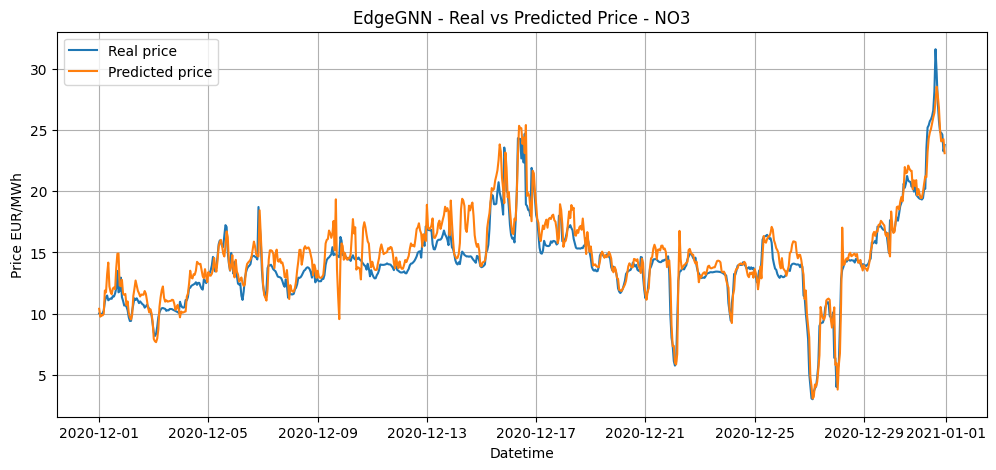

In [83]:
# ============================================================
# 24. PLOT EDGE GNN - NO3
# ============================================================

zone_to_plot = "NO3"

plot_df = results_edge[results_edge["zone_code"] == zone_to_plot].copy()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["datetime"], plot_df["y_true"], label="Real price")
plt.plot(plot_df["datetime"], plot_df["y_pred"], label="Predicted price")

plt.xlabel("Datetime")
plt.ylabel("Price EUR/MWh")
plt.title(f"EdgeGNN - Real vs Predicted Price - {zone_to_plot}")
plt.legend()
plt.grid(True)
plt.show()

In [84]:
# ============================================================
# 25. CREATE EDGE WEIGHTS FROM FLOW EDGE ATTRIBUTE
# ============================================================

def add_edge_weight_from_flow(graph):
    graph = graph.clone()
    
    # edge_attr has shape [num_edges, 1]
    # Use flow as scalar edge weight
    edge_weight = graph.edge_attr[:, 0]
    
    # Make edge weights positive and bounded
    # Since edge_attr is normalized, values can be negative.
    # We transform them with sigmoid to keep them in (0, 1).
    graph.edge_weight = torch.sigmoid(edge_weight)
    
    return graph


train_graphs_weighted = [
    add_edge_weight_from_flow(g)
    for g in train_graphs_norm
]

test_graphs_weighted = [
    add_edge_weight_from_flow(g)
    for g in test_graphs_norm
]

print(train_graphs_weighted[0])
print("edge_weight shape:", train_graphs_weighted[0].edge_weight.shape)
print("edge_weight min:", train_graphs_weighted[0].edge_weight.min())
print("edge_weight max:", train_graphs_weighted[0].edge_weight.max())

Data(x=[12, 6], edge_index=[2, 24], edge_attr=[24, 1], y=[12], datetime=2020-01-02 00:00:00, edge_weight=[24])
edge_weight shape: torch.Size([24])
edge_weight min: tensor(0.3786)
edge_weight max: tensor(0.8197)


In [86]:
# ============================================================
# 26. EDGE-WEIGHTED DATALOADERS
# ============================================================

batch_size = 32

train_loader_weighted = DataLoader(
    train_graphs_weighted,
    batch_size=batch_size,
    shuffle=False
)

test_loader_weighted = DataLoader(
    test_graphs_weighted,
    batch_size=batch_size,
    shuffle=False
)

batch_weighted = next(iter(train_loader_weighted))

print(batch_weighted)
print("Batch x:", batch_weighted.x.shape)
print("Batch edge_index:", batch_weighted.edge_index.shape)
print("Batch edge_weight:", batch_weighted.edge_weight.shape)
print("Batch y:", batch_weighted.y.shape)

DataBatch(x=[384, 6], edge_index=[2, 768], edge_attr=[768, 1], y=[384], datetime=[32], edge_weight=[768], batch=[384], ptr=[33])
Batch x: torch.Size([384, 6])
Batch edge_index: torch.Size([2, 768])
Batch edge_weight: torch.Size([768])
Batch y: torch.Size([384])


In [87]:
# ============================================================
# 27. DEFINE WEIGHTED GCN MODEL
# ============================================================

class WeightedGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, edge_weight):
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)

        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)

        out = self.lin(x).squeeze(-1)
        return out


in_channels = train_graphs_weighted[0].x.shape[1]
hidden_channels = 32

weighted_model = WeightedGCN(
    in_channels=in_channels,
    hidden_channels=hidden_channels
)

print(weighted_model)

WeightedGCN(
  (conv1): GCNConv(6, 32)
  (conv2): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=1, bias=True)
)


In [88]:
# ============================================================
# 28. TEST WEIGHTED GCN FORWARD PASS
# ============================================================

batch_weighted = next(iter(train_loader_weighted))

with torch.no_grad():
    pred = weighted_model(
        batch_weighted.x,
        batch_weighted.edge_index,
        batch_weighted.edge_weight
    )

print("Prediction shape:", pred.shape)
print("Target shape:", batch_weighted.y.shape)

print("First 10 predictions:")
print(pred[:10])

print("First 10 targets:")
print(batch_weighted.y[:10])

Prediction shape: torch.Size([384])
Target shape: torch.Size([384])
First 10 predictions:
tensor([-0.1718, -0.2431, -0.1917, -0.3806, -0.2572, -0.1975, -0.1912, -0.2043,
        -0.1089, -0.0948])
First 10 targets:
tensor([ 0.9232,  0.9232, -0.1903,  0.9232,  0.9232, -0.1903, -0.1903,  0.9232,
        -0.1903, -0.1903])


In [89]:
# ============================================================
# 29. TRAINING SETUP FOR WEIGHTED GCN
# ============================================================

weighted_model = weighted_model.to(device)

optimizer_weighted = torch.optim.Adam(
    weighted_model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

loss_fn = nn.MSELoss()

In [90]:
# ============================================================
# 30. TRAIN AND EVALUATE FUNCTIONS FOR WEIGHTED GCN
# ============================================================

def train_one_epoch_weighted(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    total_nodes = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_weight
        )

        loss = loss_fn(pred, batch.y)

        loss.backward()
        optimizer.step()

        num_nodes = batch.y.numel()
        total_loss += loss.item() * num_nodes
        total_nodes += num_nodes

    return total_loss / total_nodes


def evaluate_model_weighted(model, loader, device, y_mean, y_std):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            pred_norm = model(
                batch.x,
                batch.edge_index,
                batch.edge_weight
            )

            pred = pred_norm.cpu() * y_std + y_mean
            target = batch.y.cpu() * y_std + y_mean

            all_preds.append(pred)
            all_targets.append(target)

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2, y_true, y_pred

In [91]:
# ============================================================
# 31. TRAIN WEIGHTED GCN - SAVE BEST MODEL
# ============================================================

import copy

num_epochs = 30

train_losses_weighted = []
eval_history_weighted = []

best_rmse_weighted = float("inf")
best_epoch_weighted = None
best_model_state_weighted = None
best_metrics_weighted = None

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch_weighted(
        model=weighted_model,
        loader=train_loader_weighted,
        optimizer=optimizer_weighted,
        loss_fn=loss_fn,
        device=device
    )

    train_losses_weighted.append(train_loss)

    test_mae, test_rmse, test_r2, _, _ = evaluate_model_weighted(
        model=weighted_model,
        loader=test_loader_weighted,
        device=device,
        y_mean=y_mean,
        y_std=y_std
    )

    eval_history_weighted.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_r2": test_r2,
    })

    if test_rmse < best_rmse_weighted:
        best_rmse_weighted = test_rmse
        best_epoch_weighted = epoch
        best_model_state_weighted = copy.deepcopy(weighted_model.state_dict())
        best_metrics_weighted = {
            "MAE": test_mae,
            "RMSE": test_rmse,
            "R2": test_r2,
        }

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train loss: {train_loss:.4f} | "
            f"Test MAE: {test_mae:.4f} | "
            f"Test RMSE: {test_rmse:.4f} | "
            f"Test R2: {test_r2:.4f}"
        )

print("\nBEST WEIGHTED GCN MODEL")
print("-----------------------")
print(f"Best epoch: {best_epoch_weighted}")
print(f"Best MAE:  {best_metrics_weighted['MAE']:.4f}")
print(f"Best RMSE: {best_metrics_weighted['RMSE']:.4f}")
print(f"Best R2:   {best_metrics_weighted['R2']:.4f}")

Epoch 001 | Train loss: 0.3947 | Test MAE: 7.4887 | Test RMSE: 11.2592 | Test R2: 0.6843
Epoch 005 | Train loss: 0.2368 | Test MAE: 6.0353 | Test RMSE: 9.9717 | Test R2: 0.7524
Epoch 010 | Train loss: 0.2198 | Test MAE: 5.6893 | Test RMSE: 9.4930 | Test R2: 0.7756
Epoch 015 | Train loss: 0.2045 | Test MAE: 5.5486 | Test RMSE: 9.2807 | Test R2: 0.7855
Epoch 020 | Train loss: 0.1949 | Test MAE: 5.4352 | Test RMSE: 9.1441 | Test R2: 0.7918
Epoch 025 | Train loss: 0.1864 | Test MAE: 5.3547 | Test RMSE: 9.0537 | Test R2: 0.7959
Epoch 030 | Train loss: 0.1799 | Test MAE: 5.3191 | Test RMSE: 9.0121 | Test R2: 0.7977

BEST WEIGHTED GCN MODEL
-----------------------
Best epoch: 30
Best MAE:  5.3191
Best RMSE: 9.0121
Best R2:   0.7977


In [92]:
# ============================================================
# 32. FINAL TEST METRICS - BEST WEIGHTED GCN
# ============================================================

# Restore best model
weighted_model.load_state_dict(best_model_state_weighted)

test_mae_weighted, test_rmse_weighted, test_r2_weighted, y_true_weighted, y_pred_weighted = evaluate_model_weighted(
    model=weighted_model,
    loader=test_loader_weighted,
    device=device,
    y_mean=y_mean,
    y_std=y_std
)

print("FINAL BEST WEIGHTED GCN RESULTS")
print("-------------------------------")
print(f"Best epoch: {best_epoch_weighted}")
print(f"MAE:  {test_mae_weighted:.4f}")
print(f"RMSE: {test_rmse_weighted:.4f}")
print(f"R2:   {test_r2_weighted:.4f}")

FINAL BEST WEIGHTED GCN RESULTS
-------------------------------
Best epoch: 30
MAE:  5.3191
RMSE: 9.0121
R2:   0.7977


In [93]:
# ============================================================
# 33. CREATE RESULTS DATAFRAME FOR WEIGHTED GCN
# ============================================================

test_datetimes = []
test_zone_codes = []

for graph in test_graphs:
    for node_idx in range(graph.x.shape[0]):
        test_datetimes.append(graph.datetime)
        test_zone_codes.append(node_idx_to_zone_code[node_idx])

results_weighted = pd.DataFrame({
    "datetime": test_datetimes,
    "zone_code": test_zone_codes,
    "y_true": y_true_weighted,
    "y_pred": y_pred_weighted,
})

display(results_weighted.head(15))
display(results_weighted.tail(15))

,datetime,zone_code,y_true,y_pred
0,2020-12-01 00:00:00,DK1,25.02,20.423828
1,2020-12-01 00:00:00,DK2,25.02,19.800362
2,2020-12-01 00:00:00,FI,12.42,12.867528
3,2020-12-01 00:00:00,NO1,12.42,9.819254
4,2020-12-01 00:00:00,NO2,12.42,15.616709
5,2020-12-01 00:00:00,NO3,10.03,9.602595
6,2020-12-01 00:00:00,NO4,10.03,9.429979
7,2020-12-01 00:00:00,NO5,12.42,12.390953
8,2020-12-01 00:00:00,SE1,12.42,11.347740
9,2020-12-01 00:00:00,SE2,12.42,12.046586


,datetime,zone_code,y_true,y_pred
8913,2020-12-31 22:00:00,SE2,24.070000,27.930010
8914,2020-12-31 22:00:00,SE3,24.070000,28.812180
8915,2020-12-31 22:00:00,SE4,24.070000,46.908531
8916,2020-12-31 23:00:00,DK1,50.870003,48.382751
8917,2020-12-31 23:00:00,DK2,50.870003,55.785919
8918,2020-12-31 23:00:00,FI,24.950001,26.045818
8919,2020-12-31 23:00:00,NO1,24.950001,22.995804
8920,2020-12-31 23:00:00,NO2,24.950001,34.825199
8921,2020-12-31 23:00:00,NO3,23.770000,22.596622
8922,2020-12-31 23:00:00,NO4,18.650000,14.188440


In [94]:
# ============================================================
# 34. METRICS BY ZONE - WEIGHTED GCN
# ============================================================

zone_metrics_weighted = []

for zone_code in sorted(results_weighted["zone_code"].unique()):
    zone_df = results_weighted[results_weighted["zone_code"] == zone_code]

    mae = mean_absolute_error(zone_df["y_true"], zone_df["y_pred"])
    rmse = mean_squared_error(zone_df["y_true"], zone_df["y_pred"]) ** 0.5
    r2 = r2_score(zone_df["y_true"], zone_df["y_pred"])

    zone_metrics_weighted.append({
        "zone_code": zone_code,
        "MAE_weighted": mae,
        "RMSE_weighted": rmse,
        "R2_weighted": r2,
    })

zone_metrics_weighted_df = pd.DataFrame(zone_metrics_weighted)

display(zone_metrics_weighted_df)

,zone_code,MAE_weighted,RMSE_weighted,R2_weighted
0,DK1,10.376040,14.518265,0.594593
1,DK2,7.539428,12.053759,0.794564
2,FI,7.877560,12.531461,0.826067
3,NO1,3.965696,7.475426,0.319591
4,NO2,5.710646,8.386577,0.143458
5,NO3,3.104244,4.910616,-1.006311
6,NO4,4.007921,6.652882,-7.203254
7,NO5,2.052626,4.758577,0.476480
8,SE1,2.682374,3.811289,0.651991
9,SE2,2.475168,3.579261,0.693074


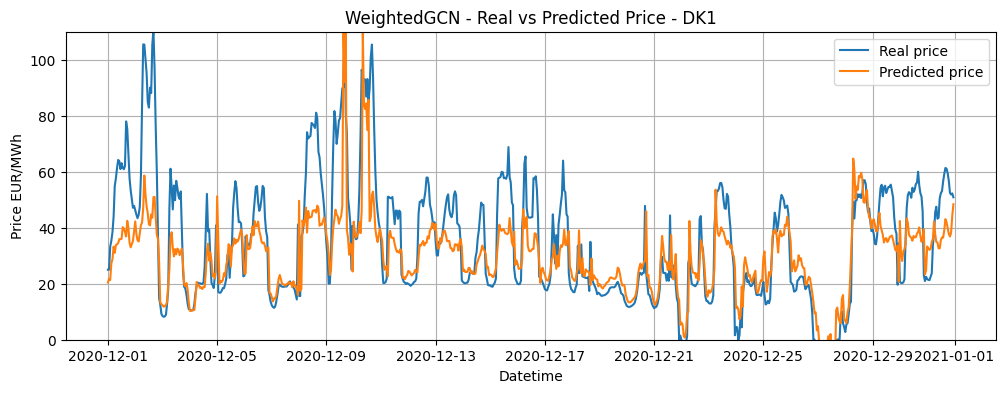

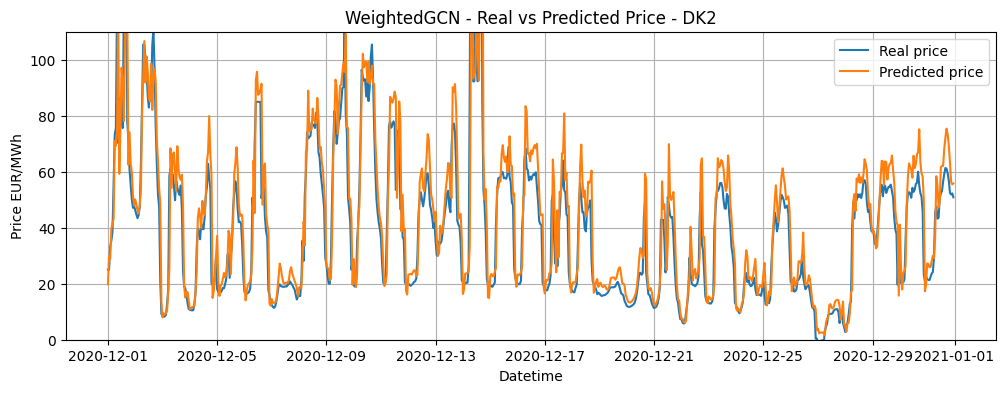

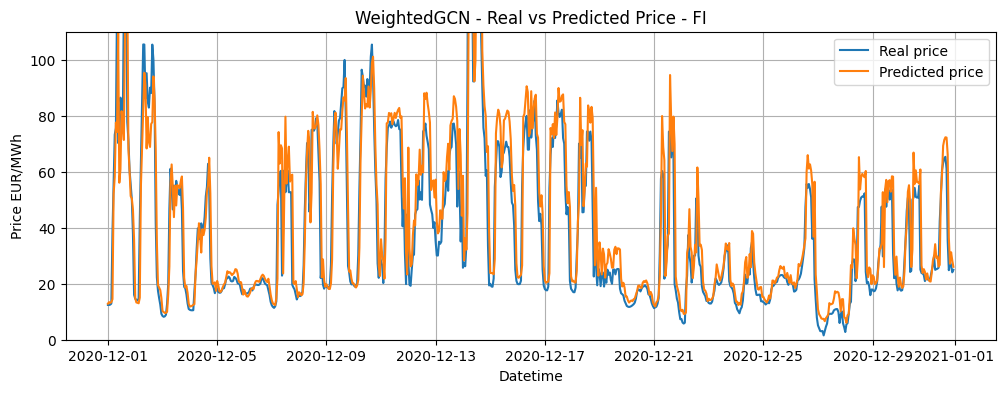

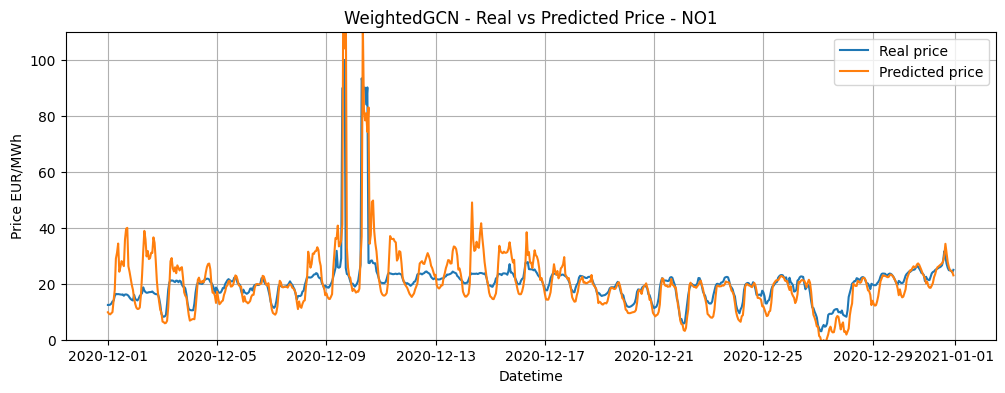

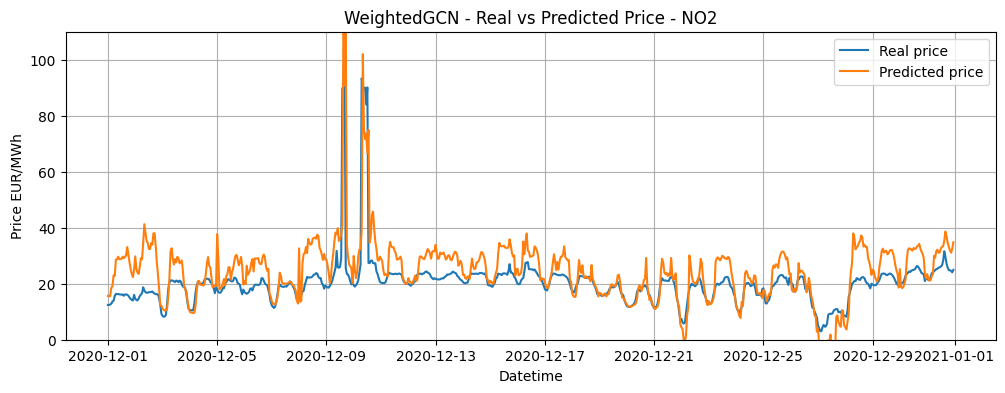

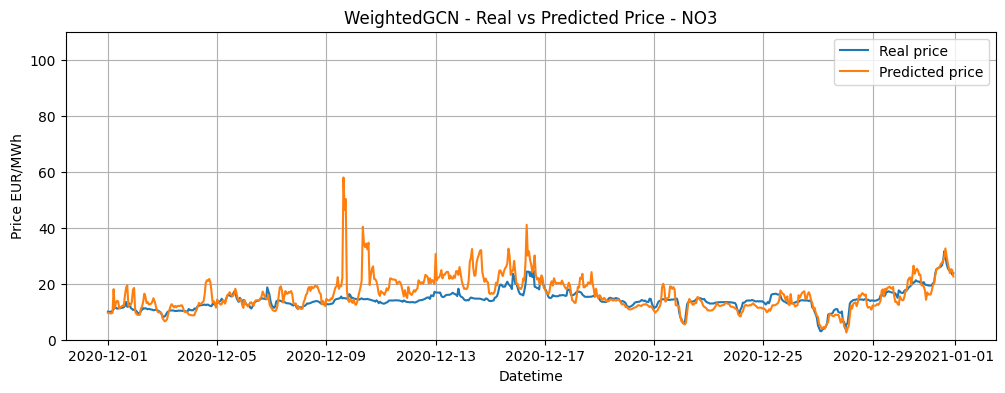

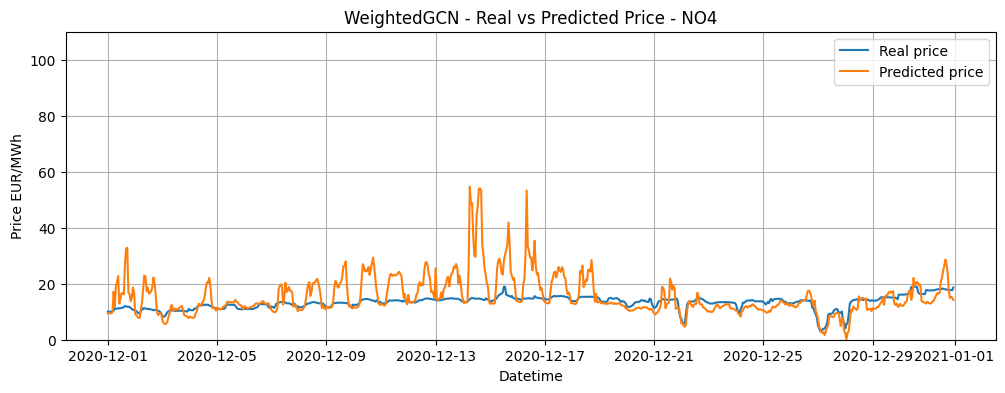

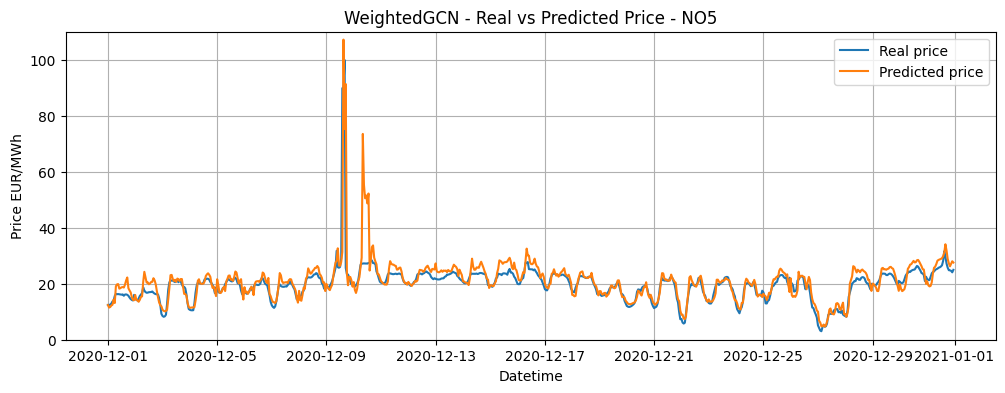

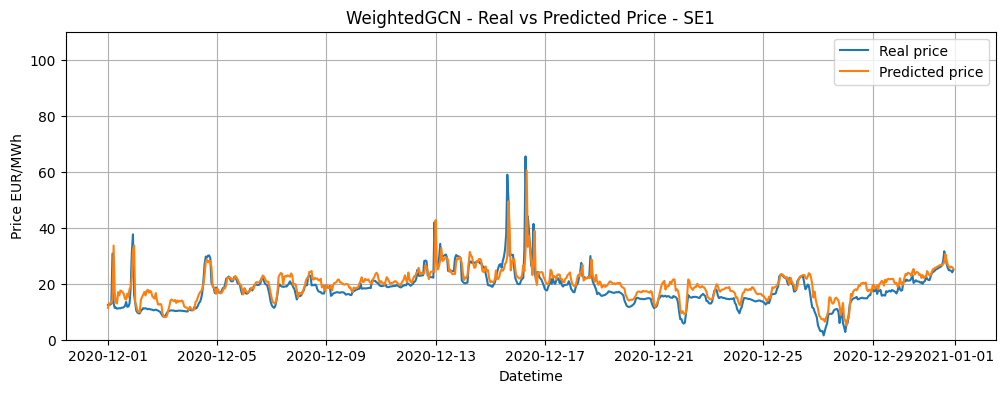

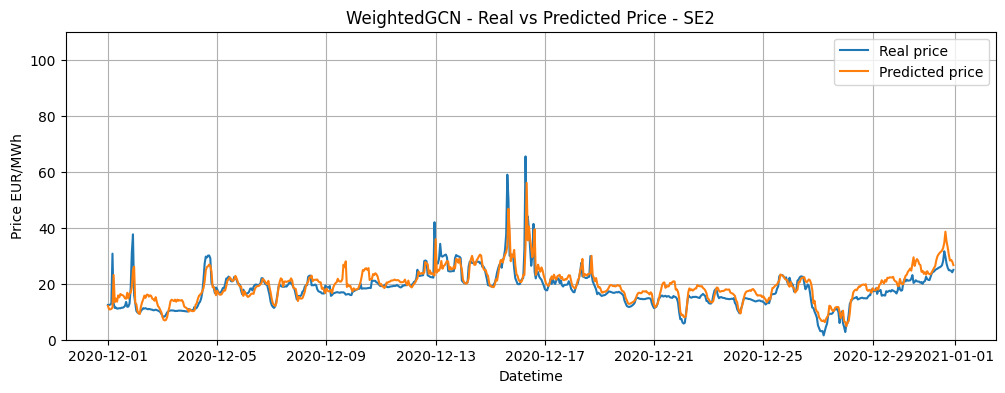

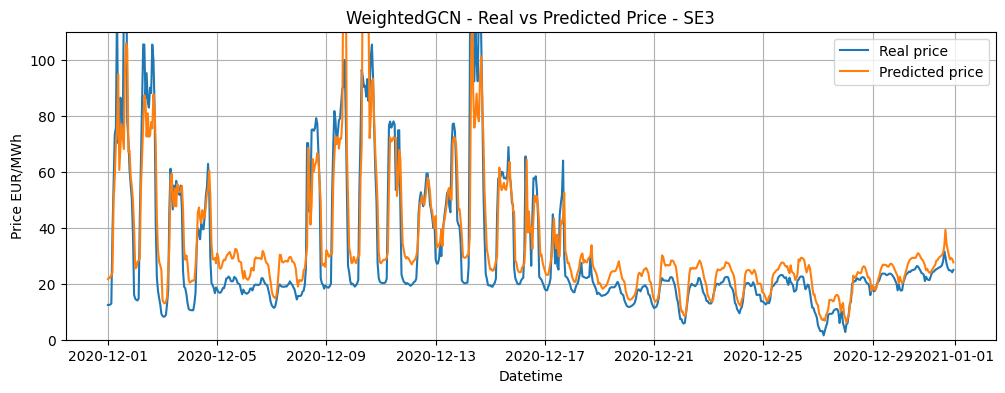

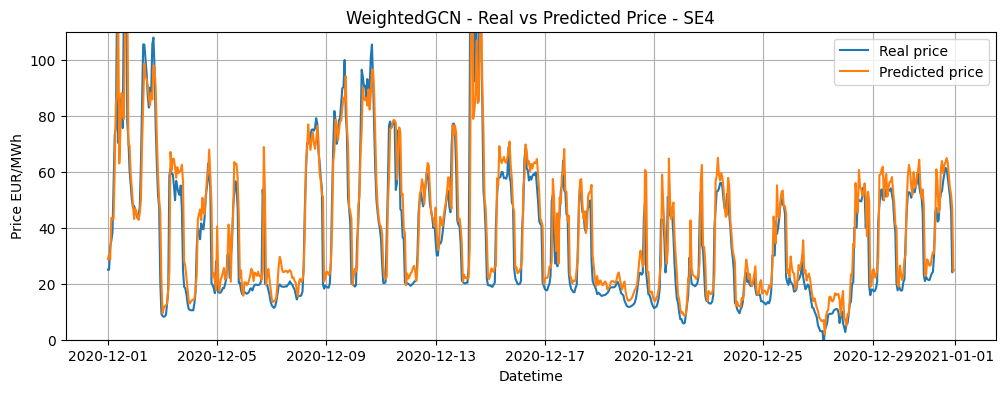

In [95]:
# ============================================================
# 35. PLOT WEIGHTED GCN PREDICTIONS FOR ALL ZONES
# ============================================================

for zone_to_plot in sorted(results_weighted["zone_code"].unique()):
    plot_df = results_weighted[results_weighted["zone_code"] == zone_to_plot].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(plot_df["datetime"], plot_df["y_true"], label="Real price")
    plt.plot(plot_df["datetime"], plot_df["y_pred"], label="Predicted price")

    plt.xlabel("Datetime")
    plt.ylabel("Price EUR/MWh")
    plt.title(f"WeightedGCN - Real vs Predicted Price - {zone_to_plot}")
    plt.ylim(0, 110)
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.show()